# UNIT IV

## SVM

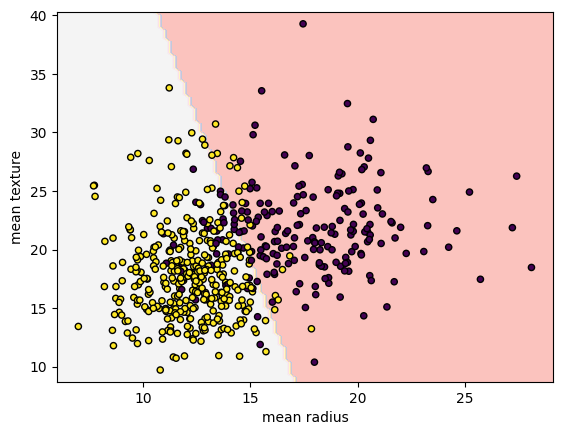

In [1]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

cancer = load_breast_cancer()
X = cancer.data[:, :2]
y = cancer.target

svm = SVC(kernel="linear", C=1)
svm.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
        svm,
        X,
        response_method="predict",
        alpha=0.8,
        cmap="Pastel1",
        xlabel=cancer.feature_names[0],
        ylabel=cancer.feature_names[1],
    )

plt.scatter(X[:, 0], X[:, 1], 
            c=y, 
            s=20, edgecolors="k")
plt.show()

## Decision Trees

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
data = load_iris()
X = data.data  
y = data.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state = 99)

In [5]:
clf = DecisionTreeClassifier(random_state=1)

In [6]:
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [8]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9555555555555556


In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, 
                           cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.9714285714285715
DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=3,
                       random_state=1)


In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
 
tree_clf = grid_search.best_estimator_

plt.figure(figsize=(18, 15))
plot_tree(tree_clf, filled=True, feature_names=iris.feature_names,
          class_names=iris.target_names)
plt.show()

NameError: name 'iris' is not defined

<Figure size 1800x1500 with 0 Axes>

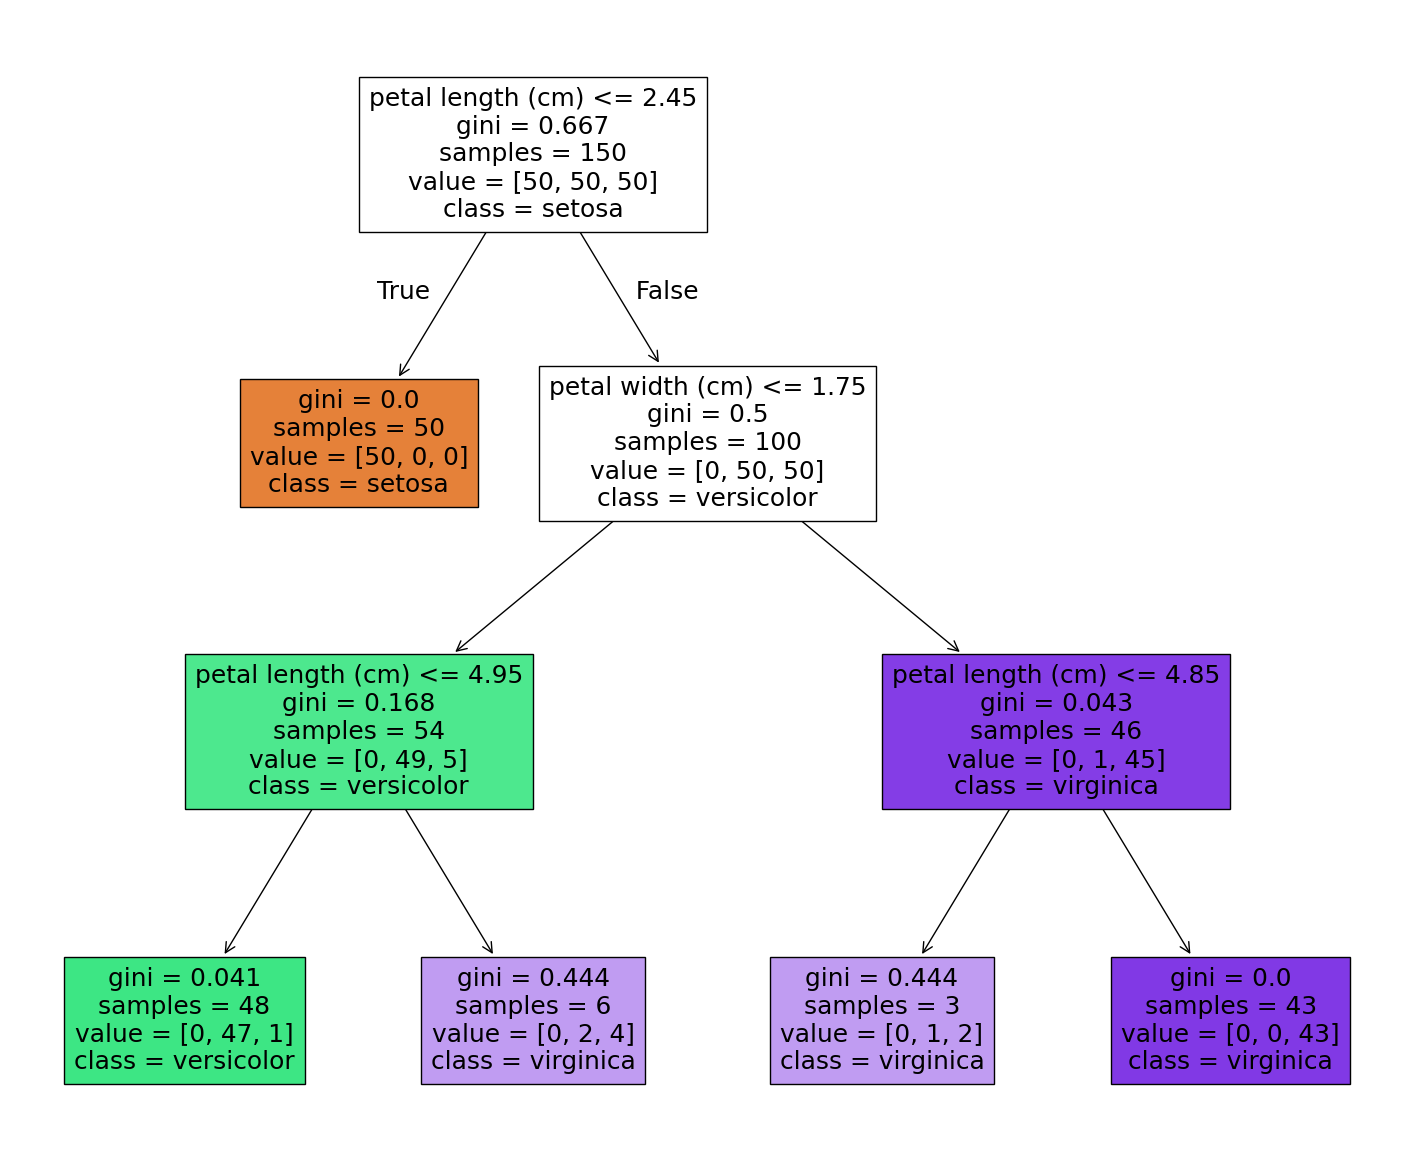

In [11]:
# Step 1: Import libraries
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Step 2: Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Step 3: Train a Decision Tree (example)
tree = DecisionTreeClassifier(random_state=42)
# Optional: Grid search for best parameters
params = {'max_depth':[2, 3, 4, 5, None]}
grid_search = GridSearchCV(tree, params, cv=5)
grid_search.fit(X, y)
tree_clf = grid_search.best_estimator_

# Step 4: Plot the tree
plt.figure(figsize=(18, 15))
plot_tree(tree_clf, filled=True, feature_names=iris.feature_names,
          class_names=iris.target_names)
plt.show()


## Clustering

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

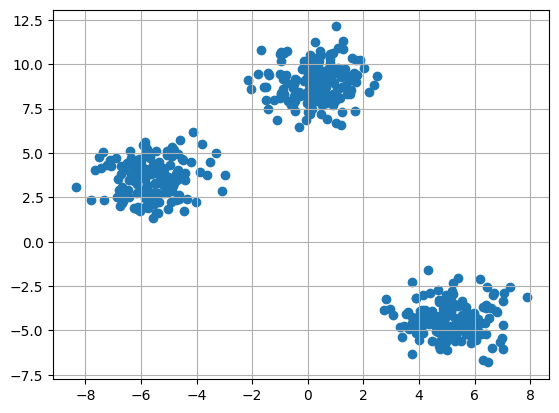

In [13]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [14]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

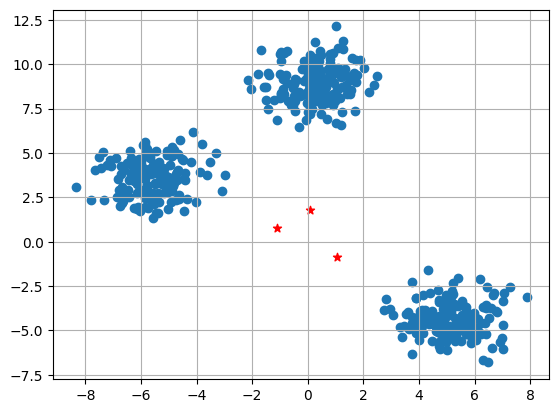

In [15]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

In [16]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

In [17]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        
        curr_x = X[idx]
        
        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center
            
            clusters[i]['points'] = []
    return clusters

In [18]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [19]:
clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

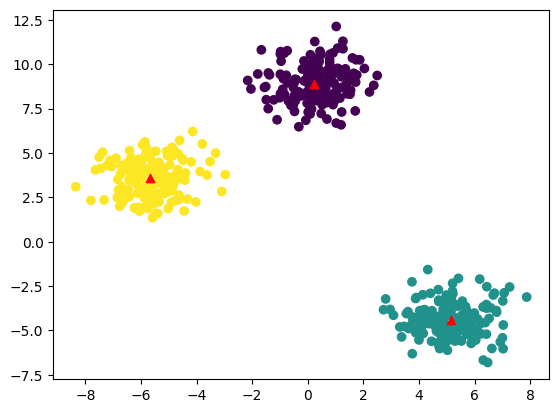

In [20]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

# UNIT I

## LINEAR REGRESSION

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [22]:
np.random.seed(42)

X = np.random.rand(50, 1) * 100  

Y = 3.5 * X + np.random.randn(50, 1) * 20

In [23]:
model = LinearRegression()
model.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
Y_pred = model.predict(X)

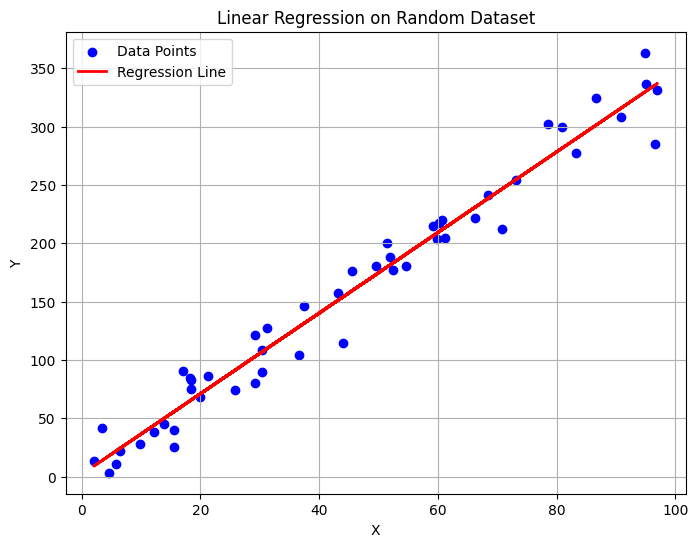

In [25]:
plt.figure(figsize=(8,6)) 
plt.scatter(X, Y, color='blue', label='Data Points') 
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
print("Slope (Coefficient):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])

Slope (Coefficient): 3.4553132007706204
Intercept: 1.9337854893777546


## NAIVE BAYES

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

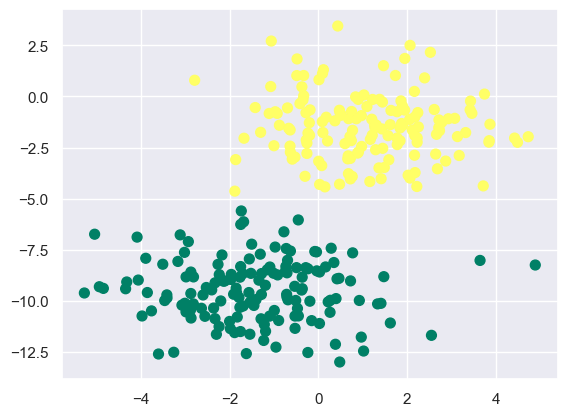

In [28]:
from sklearn.datasets import make_blobs
X, y = make_blobs(300, 2, centers=2, random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='summer');

In [29]:
from sklearn.naive_bayes import GaussianNB
model_GNB = GaussianNB()
model_GNB.fit(X, y);

In [31]:
rng = np.random.RandomState(0)
Xnew = [-6, -14] + [14, 18] * rng.rand(2000, 2)
ynew = model_GNB.predict(Xnew)

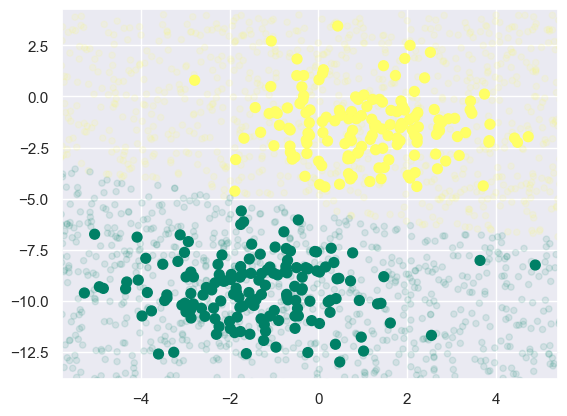

In [32]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='summer')
lim = plt.axis()
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew, s=20, cmap='summer', alpha=0.1)
plt.axis(lim);

In [33]:
yprob = model_GNB.predict_proba(Xnew)
yprob[-10:].round(3)

array([[0.998, 0.002],
       [1.   , 0.   ],
       [0.987, 0.013],
       [1.   , 0.   ],
       [1.   , 0.   ],
       [1.   , 0.   ],
       [1.   , 0.   ],
       [1.   , 0.   ],
       [0.   , 1.   ],
       [0.986, 0.014]])

## BREADTH FIRST SEARCH

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from queue import Queue

In [35]:
def visualize_puzzle(path):
    fig, axes = plt.subplots(nrows=len(path), ncols=1, figsize=(3, 3 * len(path)))
    if len(path) == 1:
        axes = [axes]
    for ax, state in zip(axes, path):
        ax.imshow(state, cmap='tab20', vmin=0, vmax=9)
        ax.set_xticks(np.arange(3))
        ax.set_yticks(np.arange(3))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        for i in range(3):
            for j in range(3):
                ax.text(j, i, state[i, j] if state[i, j] != 0 else '',
                        ha='center', va='center', color='white', fontsize=20)
        ax.grid(color='black')
    plt.tight_layout()
    plt.show()

In [36]:
def bfs_solve(initial_state, goal_state):

    queue = Queue()
    queue.put((initial_state, [initial_state]))
    visited = set()
    visited.add(tuple(initial_state.reshape(-1)))
    
    while not queue.empty():
        current_state, path = queue.get()
        if np.array_equal(current_state, goal_state):
            return path
        
        zero_pos = tuple(np.argwhere(current_state == 0)[0])
        moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

In [37]:
for move in moves:
            new_pos = (zero_pos[0] + move[0], zero_pos[1] + move[1])
            if 0 <= new_pos[0] < 3 and 0 <= new_pos[1] < 3:
                new_state = np.copy(current_state)
                new_state[zero_pos], new_state[new_pos] = new_state[new_pos], new_state[zero_pos]
                new_state_tuple = tuple(new_state.reshape(-1))
                if new_state_tuple not in visited:
                    visited.add(new_state_tuple)
                    queue.put((new_state, path + [new_state]))

NameError: name 'moves' is not defined

In [38]:
initial_state = np.array([[1, 2, 3], [4, 5, 6], [0, 7, 8]])
goal_state = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 0]])
solution_path = bfs_solve(initial_state, goal_state)
if solution_path:
    visualize_puzzle(solution_path)
else:
    print("No solution found.")

No solution found.


In [39]:
import numpy as np
from queue import Queue

# Initial puzzle state
start_state = np.array([[1, 2, 3],
                        [4, 0, 5],
                        [6, 7, 8]])

# Goal puzzle state
goal_state = np.array([[1, 2, 3],
                       [4, 5, 0],
                       [6, 7, 8]])

# Moves: up, down, left, right
moves = [(-1,0), (1,0), (0,-1), (0,1)]

# BFS setup
queue = Queue()
queue.put((start_state, [start_state]))
visited = set()
visited.add(tuple(start_state.reshape(-1)))

while not queue.empty():
    current_state, path = queue.get()
    
    if np.array_equal(current_state, goal_state):
        print("Goal reached!")
        print("Number of moves:", len(path)-1)
        break
    
    zero_pos = tuple(np.argwhere(current_state == 0)[0])
    
    for move in moves:
        new_pos = (zero_pos[0] + move[0], zero_pos[1] + move[1])
        
        if 0 <= new_pos[0] < 3 and 0 <= new_pos[1] < 3:
            new_state = np.copy(current_state)
            new_state[zero_pos], new_state[new_pos] = new_state[new_pos], new_state[zero_pos]
            
            new_state_tuple = tuple(new_state.reshape(-1))
            if new_state_tuple not in visited:
                visited.add(new_state_tuple)
                queue.put((new_state, path + [new_state]))


Goal reached!
Number of moves: 1


In [40]:
from collections import deque

# Graph as an adjacency list
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# Initialize the queue, visited set, and result list
queue = deque()         
visited = set()          
traversal_order = []

In [41]:
start_node = 'A'
queue.append(start_node)   # Enqueue node A
visited.add(start_node)    # Mark A as visited

In [42]:
while queue:
    current = queue.popleft()            
    traversal_order.append(current)      

    for neighbor in graph[current]:      
        if neighbor not in visited:
            queue.append(neighbor)       # Enqueue unvisited neighbor
            visited.add(neighbor)        # Mark it visited

In [43]:
print("\nFinal Traversal Order:")
print(" → ".join(traversal_order))


Final Traversal Order:
A → B → C → D → E → F


In [44]:
class Node:
    def __init__(self, state, parent=None, action=None):
        self.state = state
        self.parent = parent
        self.action = action

In [45]:
from collections import deque

class GridProblem:
    def __init__(self, initial_state, goal_state, grid):
        self.initial_state = initial_state
        self.goal_state = goal_state
        self.grid = grid

    def is_goal(self, state):
        return state == self.goal_state

    def is_valid_cell(self, row, col):
        return 0 <= row < len(self.grid) and 0 <= col < len(self.grid[0]) and self.grid[col][row] == 0

    def expand(self, node):
        row, col = node.state
        children = []
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            new_row, new_col = row + dr, col + dc
            if self.is_valid_cell(new_row, new_col):
                child_state = (new_row, new_col)
                child_node = Node(child_state, parent=node)
                children.append(child_node)
        return children

In [46]:
def reconstruct_path(node):
    path = []
    while node:
        path.append(node.state)
        node = node.parent
    return list(reversed(path))


# Function to print the complete path
def print_complete_path(path):
    for step, point in enumerate(path):
        print("Step {}: {}".format(step, point))

In [48]:
# Example usage and grid definition
"""
    1 : Denotes the obstacles
    0 : Empty space or a non-obstacle cell in the grid
"""
grid = [
    [0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0]
]

# Define initial and goal states
initial_state = (0, 0)
goal_state = (6, 0)

# Define the problem instance
problem = GridProblem(initial_state, goal_state, grid)

# Perform breadth-first search to find a solution
solution_node = breadth_first_search(problem)

# Print solution if found
print('!! Reached the Goal!!' if solution_node else None)
if solution_node:
    print("Solution found!")
    solution_path = reconstruct_path(solution_node)
    print("Complete Path:")
    print_complete_path(solution_path)
else:
    print("No solution found")

NameError: name 'breadth_first_search' is not defined

In [49]:
# Example usage and grid definition
"""
    1 : Denotes the obstacles
    0 : Empty space or a non-obstacle cell in the grid
"""
grid = [
    [0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0]
]

# Define initial and goal states
initial_state = (0, 0)
goal_state = (6, 0)

# Define the problem instance
problem = GridProblem(initial_state, goal_state, grid)

# Perform breadth-first search to find a solution
solution_node = breadth_first_search(problem)

# Print solution if found
print('!! Reached the Goal!!' if solution_node else None)
if solution_node:
    print("Solution found!")
    solution_path = reconstruct_path(solution_node)
    print("Complete Path:")
    print_complete_path(solution_path)
else:
    print("No solution found")

NameError: name 'breadth_first_search' is not defined

In [50]:
from collections import deque

class GridProblem:
    def __init__(self, start, goal, grid):
        self.start = start
        self.goal = goal
        self.grid = grid
        self.rows = len(grid)
        self.cols = len(grid[0])
    
    def get_neighbors(self, position):
        moves = [(-1,0),(1,0),(0,-1),(0,1)]  # up, down, left, right
        neighbors = []
        for move in moves:
            new_r, new_c = position[0]+move[0], position[1]+move[1]
            if 0 <= new_r < self.rows and 0 <= new_c < self.cols:
                if self.grid[new_r][new_c] != 1:  # 1 = obstacle
                    neighbors.append((new_r, new_c))
        return neighbors

def breadth_first_search(problem):
    start = problem.start
    goal = problem.goal
    queue = deque()
    queue.append((start, [start]))  # node and path
    visited = set()
    visited.add(start)
    
    while queue:
        current, path = queue.popleft()
        
        if current == goal:
            return path  # return path to goal
        
        for neighbor in problem.get_neighbors(current):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    
    return None  # if no path found

# Example usage
grid = [
    [0,0,0,0],
    [0,1,1,0],
    [0,0,0,0],
    [0,1,0,0]
]

initial_state = (0,0)
goal_state = (3,3)

problem = GridProblem(initial_state, goal_state, grid)
solution_node = breadth_first_search(problem)

print('Path to goal:' if solution_node else 'No path found', solution_node)


Path to goal: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3)]


## DEPTH FIRST SEARCH

In [51]:
def dfsRec(adj, visited, s, res):
    visited[s] = True
    res.append(s)

    # Recursively visit all adjacent vertices 
    # that are not visited yet
    for i in adj[s]:
        if not visited[i]:
            dfsRec(adj, visited, i, res)


def dfs(adj):
    visited = [False] * len(adj)
    res = []
    dfsRec(adj, visited, 0, res)
    return res

def addEdge(adj, u, v):
    adj[u].append(v)
    adj[v].append(u)
    
    
if __name__ == "__main__":
    V = 5
    adj = []
    
    # creating adjacency list
    for i in range(V):
        adj.append([])
        
    addEdge(adj, 1, 2)
    addEdge(adj, 1, 0)
    addEdge(adj, 2, 0)
    addEdge(adj, 2, 3)
    addEdge(adj, 2, 4)

    # Perform DFS starting from vertex 0
    res = dfs(adj)

    for node in res:
        print(node, end=" ")

0 1 2 3 4 

In [52]:
from collections import defaultdict

def dfsRec(adj, visited, s, res):
    visited[s] = True
    res.append(s)

    # Recursively visit all adjacent 
    # vertices that are not visited yet
    for i in adj[s]:
        if not visited[i]:
            dfsRec(adj, visited, i, res)


def dfs(adj):
    visited = [False] * len(adj)
    res = []
    # Loop through all vertices to 
    # handle disconnected graph
    for i in range(len(adj)):
        if not visited[i]:
            dfsRec(adj, visited, i, res)
    return res

def addEdge(adj, u, v):
    adj[u].append(v)
    adj[v].append(u)
  
  
if __name__ == "__main__":
    V = 6
    adj = []
    
    # creating adjacency list
    for i in range(V):
        adj.append([])
        
    addEdge(adj, 1, 2)
    addEdge(adj, 2, 0)
    addEdge(adj, 0, 3)
    addEdge(adj, 5, 4)
    
    # Perform DFS
    res = dfs(adj)
    
    print(*res)


0 2 1 3 4 5


## A* ALGORITHM

In [53]:
import math
import heapq

# Define the Cell class
class Cell:
    def __init__(self):
        self.parent_i = 0  # Parent cell's row index
        self.parent_j = 0  # Parent cell's column index
        self.f = float('inf')  # Total cost of the cell (g + h)
        self.g = float('inf')  # Cost from start to this cell
        self.h = 0  # Heuristic cost from this cell to destination

# Define the size of the grid
ROW = 9
COL = 10

# Check if a cell is valid (within the grid)
def is_valid(row, col):
    return (row >= 0) and (row < ROW) and (col >= 0) and (col < COL)

# Check if a cell is unblocked
def is_unblocked(grid, row, col):
    return grid[row][col] == 1

# Check if a cell is the destination
def is_destination(row, col, dest):
    return row == dest[0] and col == dest[1]

# Calculate the heuristic value of a cell (Euclidean distance to destination)
def calculate_h_value(row, col, dest):
    return ((row - dest[0]) ** 2 + (col - dest[1]) ** 2) ** 0.5

# Trace the path from source to destination
def trace_path(cell_details, dest):
    print("The Path is ")
    path = []
    row = dest[0]
    col = dest[1]

    # Trace the path from destination to source using parent cells
    while not (cell_details[row][col].parent_i == row and cell_details[row][col].parent_j == col):
        path.append((row, col))
        temp_row = cell_details[row][col].parent_i
        temp_col = cell_details[row][col].parent_j
        row = temp_row
        col = temp_col

    # Add the source cell to the path
    path.append((row, col))
    # Reverse the path to get the path from source to destination
    path.reverse()

    # Print the path
    for i in path:
        print("->", i, end=" ")
    print()

# Implement the A* search algorithm
def a_star_search(grid, src, dest):
    # Check if the source and destination are valid
    if not is_valid(src[0], src[1]) or not is_valid(dest[0], dest[1]):
        print("Source or destination is invalid")
        return

    # Check if the source and destination are unblocked
    if not is_unblocked(grid, src[0], src[1]) or not is_unblocked(grid, dest[0], dest[1]):
        print("Source or the destination is blocked")
        return

    # Check if we are already at the destination
    if is_destination(src[0], src[1], dest):
        print("We are already at the destination")
        return

    # Initialize the closed list (visited cells)
    closed_list = [[False for _ in range(COL)] for _ in range(ROW)]
    # Initialize the details of each cell
    cell_details = [[Cell() for _ in range(COL)] for _ in range(ROW)]

    # Initialize the start cell details
    i = src[0]
    j = src[1]
    cell_details[i][j].f = 0
    cell_details[i][j].g = 0
    cell_details[i][j].h = 0
    cell_details[i][j].parent_i = i
    cell_details[i][j].parent_j = j

    # Initialize the open list (cells to be visited) with the start cell
    open_list = []
    heapq.heappush(open_list, (0.0, i, j))

    # Initialize the flag for whether destination is found
    found_dest = False

    # Main loop of A* search algorithm
    while len(open_list) > 0:
        # Pop the cell with the smallest f value from the open list
        p = heapq.heappop(open_list)

        # Mark the cell as visited
        i = p[1]
        j = p[2]
        closed_list[i][j] = True

        # For each direction, check the successors
        directions = [(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]
        for dir in directions:
            new_i = i + dir[0]
            new_j = j + dir[1]

            # If the successor is valid, unblocked, and not visited
            if is_valid(new_i, new_j) and is_unblocked(grid, new_i, new_j) and not closed_list[new_i][new_j]:
                # If the successor is the destination
                if is_destination(new_i, new_j, dest):
                    # Set the parent of the destination cell
                    cell_details[new_i][new_j].parent_i = i
                    cell_details[new_i][new_j].parent_j = j
                    print("The destination cell is found")
                    # Trace and print the path from source to destination
                    trace_path(cell_details, dest)
                    found_dest = True
                    return
                else:
                    # Calculate the new f, g, and h values
                    g_new = cell_details[i][j].g + 1.0
                    h_new = calculate_h_value(new_i, new_j, dest)
                    f_new = g_new + h_new

                    # If the cell is not in the open list or the new f value is smaller
                    if cell_details[new_i][new_j].f == float('inf') or cell_details[new_i][new_j].f > f_new:
                        # Add the cell to the open list
                        heapq.heappush(open_list, (f_new, new_i, new_j))
                        # Update the cell details
                        cell_details[new_i][new_j].f = f_new
                        cell_details[new_i][new_j].g = g_new
                        cell_details[new_i][new_j].h = h_new
                        cell_details[new_i][new_j].parent_i = i
                        cell_details[new_i][new_j].parent_j = j

    # If the destination is not found after visiting all cells
    if not found_dest:
        print("Failed to find the destination cell")

def main():
    # Define the grid (1 for unblocked, 0 for blocked)
    grid = [
        [1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 0, 1, 1, 1, 0, 1, 1],
        [1, 1, 1, 0, 1, 1, 0, 1, 0, 1],
        [0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
        [1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
        [1, 0, 1, 1, 1, 1, 0, 1, 0, 0],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 0, 0, 0, 1, 0, 0, 1]
    ]

    # Define the source and destination
    src = [8, 0]
    dest = [0, 0]

    # Run the A* search algorithm
    a_star_search(grid, src, dest)

if __name__ == "__main__":
    main()

The destination cell is found
The Path is 
-> (8, 0) -> (7, 0) -> (6, 0) -> (5, 0) -> (4, 1) -> (3, 2) -> (2, 1) -> (1, 0) -> (0, 0) 


## BEST FIRST SEARCH

In [54]:
# Function to perform Best First Search
from heapq import heappush, heappop

def bestFirstSearch(edges, src, target, n):
    
    # create the adjacency list
    adj = [[] for _ in range(n)]
    for edge in edges:
        adj[edge[0]].append([edge[1], edge[2]])
        adj[edge[1]].append([edge[0], edge[2]])
    
    # create a visited array to 
    # keep track of visited nodes
    visited = [False] * n
    
    # create the min heap to store the nodes
    # based on the cost
    pq = []
    
    # push the source node in the min heap
    heappush(pq, [0, src])
    
    # mark the source node as visited
    visited[src] = True
    
    # to store the path   
    path = []
    
    # loop until the min heap is empty
    while pq:
        # get the top element of the min heap
        x = heappop(pq)[1]
        
        # push the current node in the path
        path.append(x)
        
        # if the current node is the target node
        # break the loop
        if x == target:
            break
        
        # loop through the edges of the current node
        for edge in adj[x]:
            if not visited[edge[0]]:
                # mark the node as visited
                visited[edge[0]] = True
                # push the node in the min heap
                heappush(pq, [edge[1], edge[0]])
    
    return path

if __name__ == "__main__":
    n = 14
    edgeList = [
        [0, 1, 3], [0, 2, 6], [0, 3, 5],
        [1, 4, 9], [1, 5, 8], [2, 6, 12],
        [2, 7, 14], [3, 8, 7], [8, 9, 5],
        [8, 10, 6], [9, 11, 1], [9, 12, 10],
        [9, 13, 2]
    ]
    source = 0
    target = 9
    path = bestFirstSearch(edgeList, source, target, n)
    for i in range(len(path)):
        print(path[i], end=" ")

0 1 3 2 8 9 

## MINMAX ALGORITHM

In [55]:
def minmax(state, depth, maximizing_player):
    if is_terminal(state) or depth == 0:
        return utility(state)
    
    if maximizing_player:
        max_eval = -infinity
        for action in actions(state):
            eval = minmax(result(state, action), depth-1, False)
            max_eval = max(max_eval, eval)
        return max_eval
    else:
        min_eval = infinity
        for action in actions(state):
            eval = minmax(result(state, action), depth-1, True)
            min_eval = min(min_eval, eval)
        return min_eval


In [56]:
def alpha_beta_minmax(state, depth, alpha, beta, maximizing_player):
    if is_terminal(state) or depth == 0:
        return utility(state)
    
    if maximizing_player:
        max_eval = -infinity
        for action in actions(state):
            eval = alpha_beta_minmax(result(state, action), depth-1, alpha, beta, False)
            max_eval = max(max_eval, eval)
            alpha = max(alpha, eval)
            if beta <= alpha:
                break  # Beta cut-off
        return max_eval
    else:
        min_eval = infinity
        for action in actions(state):
            eval = alpha_beta_minmax(result(state, action), depth-1, alpha, beta, True)
            min_eval = min(min_eval, eval)
            beta = min(beta, eval)
            if beta <= alpha:
                break  # Alpha cut-off
        return min_eval


## ALPHA BETA PRUNING

In [58]:
import matplotlib.pyplot as plt
import networkx as nx
import pydot
import io

In [59]:
class Node:
    def __init__(self, name, children=None, value=None):
        self.name = name
        self.children = children if children is not None else []
        self.value = value

In [60]:
def evaluate(node):
    return node.value

def is_terminal(node):
    return node.value is not None

def get_children(node):
    return node.children

In [61]:
visited_edges = []

def alpha_beta_pruning(node, depth, alpha, beta, maximizing_player):
    global visited_edges

    if depth == 0 or is_terminal(node):
        return evaluate(node)

    if maximizing_player:
        max_eval = float('-inf')
        for child in get_children(node):
            visited_edges.append((node.name, child.name, "visit"))
            val = alpha_beta_pruning(child, depth - 1, alpha, beta, False)
            max_eval = max(max_eval, val)
            alpha = max(alpha, val)
            if beta <= alpha:
                visited_edges.append((node.name, child.name, "cut"))
                break
        return max_eval

    else:
        min_eval = float('inf')
        for child in get_children(node):
            visited_edges.append((node.name, child.name, "visit"))
            val = alpha_beta_pruning(child, depth - 1, alpha, beta, True)
            min_eval = min(min_eval, val)
            beta = min(beta, val)
            if beta <= alpha:
                visited_edges.append((node.name, child.name, "cut"))
                break
        return min_eval

In [62]:
D = Node('D', value=3)
E = Node('E', value=5)
F = Node('F', value=6)
G = Node('G', value=9)
H = Node('H', value=1)
I = Node('I', value=2)

B = Node('B', children=[D, E, F])
C = Node('C', children=[G, H, I])

A = Node('A', children=[B, C])

In [63]:
best = alpha_beta_pruning(A, 3, float('-inf'), float('inf'), True)
print("Optimal Value =", best)


def build_graph(G, node):
    for child in node.children:
        G.add_edge(node.name, child.name)
        build_graph(G, child)

G = nx.DiGraph()
build_graph(G, A)

g = nx.drawing.nx_pydot.to_pydot(G)
g.set_rankdir("TB")
png_str = g.create_png()

plt.figure(figsize=(8, 6))

plt.imshow(plt.imread(io.BytesIO(png_str))) 
plt.axis("off")
plt.show()

Optimal Value = 3


FileNotFoundError: [WinError 2] "dot" not found in path.

In [64]:
edge_colors = []
for u, v in G.edges():
    status = None
    for (s, d, t) in visited_edges:
        if s == u and d == v:
            status = t
            break
    if status == "visit":
        edge_colors.append("green")
    elif status == "cut":
        edge_colors.append("red")
    else:
        edge_colors.append("black")

plt.figure(figsize=(10, 7))
pos = nx.nx_pydot.graphviz_layout(G, prog='dot')
nx.draw(G, pos, with_labels=True, arrows=False, node_size=2000,
        node_color="lightblue", font_size=12, edge_color=edge_colors, width=3)
plt.title("Alpha–Beta Pruning (Green = Visited, Red = Pruned)")
plt.axis("off")
plt.show()

FileNotFoundError: [WinError 2] "dot" not found in path.

<Figure size 1000x700 with 0 Axes>

In [65]:
import math

def alpha_beta(node, depth, alpha, beta, maximizingPlayer):
    """
    Alpha-Beta pruning implementation.
    
    node: Nested list/tree structure or leaf value
    depth: Current depth in tree
    alpha: Best value for maximizer so far
    beta: Best value for minimizer so far
    maximizingPlayer: True if it's maximizing player's turn
    """
    # If leaf node, return its value
    if not isinstance(node, list):
        return node
    
    if maximizingPlayer:
        max_eval = -math.inf
        for child in node:
            eval = alpha_beta(child, depth+1, alpha, beta, False)
            max_eval = max(max_eval, eval)
            alpha = max(alpha, eval)
            if beta <= alpha:
                # Prune remaining children
                break
        return max_eval
    else:
        min_eval = math.inf
        for child in node:
            eval = alpha_beta(child, depth+1, alpha, beta, True)
            min_eval = min(min_eval, eval)
            beta = min(beta, eval)
            if beta <= alpha:
                # Prune remaining children
                break
        return min_eval

# Example Game Tree (nested lists)
# Maximizing player starts at top
# Leaf nodes represent the utility values for Maximizer
game_tree = [
    [3, 5, [6, 9]],
    [1, 2, [0, -1]],
    [[7, 4], 2, 8]
]

# Run Alpha-Beta Pruning
optimal_value = alpha_beta(game_tree, depth=0, alpha=-math.inf, beta=math.inf, maximizingPlayer=True)
print("Optimal Value for Maximizer:", optimal_value)


Optimal Value for Maximizer: 3
